In [ ]:
! pip install feature_engine==1.8.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.1/357.1 kB 9.7 MB/s eta 0:00:00


In [ ]:
!pip install optuna==4.8.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.1 MB/s eta 0:00:00


In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2 -q

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 65.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# !pip uninstall lightgbm -y
!pip install lightgbm

In [ ]:
import torch
print(torch.cuda.is_available()) # Deve retornar True no Colab com GPU ativa

True


In [ ]:
import pandas as pd
import numpy as np
import sys
import gc
import random
import os

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt

import feature_engine
from feature_engine.selection import (
    RecursiveFeatureElimination,
    DropConstantFeatures,
    DropDuplicateFeatures,
)
import optuna

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import sklearn

import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import torch

import time

import tensorflow as tf

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print("Feature Engine:", feature_engine.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Optuna:", optuna.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)
print("Tensorflow", tf.__version__)
print("PyTorch", torch.__version__)

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
Feature Engine: 1.8.0
Scikit-Learn: 1.5.2
Optuna: 4.8.0
XGBoost: 3.2.0
LightGBM: 4.6.0
Tensorflow 2.20.0
PyTorch 2.10.0+cu128


In [ ]:
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Garante que as operações na GPU sejam determinísticas (pode reduzir sutilmente a performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [ ]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [ ]:
path = f'{path_main}/df_feat.csv'
df = get_data_frame(path)

In [ ]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

In [ ]:
df.shape, df.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [ ]:
def print_nan(df):
    nan_count = df.isna().sum()
    # Filtra apenas onde a contagem é maior que zero
    nan_only = nan_count[nan_count > 0].sort_values(ascending=False)

    if nan_only.empty:
        print("Nenhum valor NaN encontrado!")
    else:
        print("Colunas com valores NaN:")
        print(nan_only)

In [ ]:
print_nan(df)

Nenhum valor NaN encontrado!


### Train Test Split

In [ ]:
# Separar o df
def train_test_split_by_date(
    data: pd.DataFrame | pd.Series,
    start_date: str,
    split_date: str,
    end_date: str | None = None,
):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data must have a DatetimeIndex")

    # garantir ordem temporal
    data = data.sort_index()

    start_date = pd.to_datetime(start_date)
    split_date = pd.to_datetime(split_date)
    end_date = pd.to_datetime(end_date) if end_date else data.index.max()

    if not (start_date < split_date < end_date):
        raise ValueError("start_date < split_date < end_date is required")

    # slicing robusto (não depende da data existir no índice)
    start_pos = data.index.searchsorted(start_date, side="left")
    end_pos = data.index.searchsorted(end_date, side="right")

    data = data.iloc[start_pos:end_pos]

    split_pos = data.index.searchsorted(split_date, side="right")
    train = data.iloc[:split_pos]
    test = data.iloc[split_pos:]

    return train, test

In [ ]:
start_date = df.index.min().strftime('%Y-%m-%d')
split_date_test = '2025-12-24' # 60 dias maior lag gerado
split_date_validation = '2025-08-26' # 60 dias
end_date = df.index.max().strftime('%Y-%m-%d')

start_date, split_date_validation, split_date_test, end_date

('2020-03-01', '2025-08-26', '2025-12-24', '2026-04-23')

In [ ]:
df_train_temp, df_test = train_test_split_by_date(df, start_date, split_date_test, end_date)

In [ ]:
df_train, df_val = train_test_split_by_date(df_train_temp, start_date, split_date_validation, split_date_test)

In [ ]:
df_train.shape, df_train.index.unique()

((2005, 66),
 DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None))

In [ ]:
df_val.shape, df_val.index.unique()

((120, 66),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [ ]:
df_test.shape, df_test.index.unique()

((120, 66),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
                '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01',
                '2026-01-02', '2026-01-03',
                ...
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [ ]:
df_train.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,...,2005.000000,2.005000e+03,2005.000000,2.005000e+03,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2.005000e+03
mean,44.942643,11.634130,30.729394,11.804140,30.199594,18.566284,78.124558,2022.415960,6.426434,2.999002,...,-0.000062,2.698475e-04,0.000360,-1.735400e-04,-0.001930,0.001402,0.001745,0.057908,-0.001244,7.505943e-05
std,129.641138,0.274246,8.451706,33.359878,4.177824,3.094147,7.382627,1.612868,3.344522,2.001745,...,0.707411,7.071557e-01,0.707530,7.070360e-01,0.707053,0.707509,0.706841,0.705349,0.706845,7.077203e-01
min,0.000000,9.000000,0.000000,0.000000,18.700000,8.300000,39.593750,2020.000000,1.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000,-0.994522,-0.999963,-0.999991,-0.999963,-9.999907e-01
25%,3.000000,11.517241,26.666667,0.000000,27.100000,16.400000,73.958333,2021.000000,4.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-0.669131,-0.743145,-0.708627,-0.648630,-0.708627,-7.055836e-01
50%,11.000000,11.625000,30.363636,0.200000,30.200000,19.000000,78.468750,2022.000000,6.000000,3.000000,...,-0.222521,-4.311252e-14,-0.222521,-6.073010e-14,-0.104528,0.000000,0.004304,0.128748,0.004304,2.572996e-15
75%,35.000000,11.765957,33.924781,6.200000,33.300000,21.000000,83.171875,2024.000000,9.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,0.669131,0.743145,0.702527,0.752667,0.702527,7.055836e-01
max,1501.000000,12.000000,68.000000,520.600000,42.500000,25.400000,95.359375,2025.000000,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000,0.994522,1.000000,0.999991,1.000000,9.999907e-01


In [ ]:
df_val.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120.000000,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,7.366667,11.573481,28.250134,8.280000,30.158333,18.225000,77.165972,2025.0,10.316667,2.991667,...,0.005196,-6.515262e-03,-0.001854,8.124399e-03,-1.580911e-16,-2.914335e-17,-0.462306,-0.691084,-0.162612,0.393777
std,2.857787,0.179567,6.356627,18.324496,4.261762,2.414426,8.187556,0.0,1.173828,2.002082,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.454632,0.323388,0.741514,0.524911
min,2.000000,11.142857,14.305556,0.000000,21.500000,12.100000,51.916667,2025.0,8.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,-0.999963,-0.999991,-0.999963,-0.763889
25%,5.000000,11.500000,24.809524,0.000000,27.175000,16.825000,72.373698,2025.0,9.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,-0.891957,-0.966289,-0.867432,0.023667
50%,7.000000,11.563492,27.734848,0.200000,29.850000,18.400000,78.645833,2025.0,10.000000,3.000000,...,-0.222521,-1.724402e-13,-0.222521,-2.429798e-13,5.342948e-15,-1.225080e-14,-0.555997,-0.831140,-0.381633,0.512367
75%,9.000000,11.675000,31.664773,8.200000,32.900000,19.825000,82.998698,2025.0,11.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,-0.077384,-0.452060,0.591195,0.868519
max,16.000000,12.000000,52.166667,134.400000,40.000000,22.800000,95.046875,2025.0,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,0.421101,0.043022,0.999852,0.999991


In [ ]:
df_test.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,10.550000,11.592108,32.377215,23.183333,32.079583,21.496667,82.836634,2025.941667,2.966667,3.0,...,0.005196,6.515262e-03,-0.001854,-8.124399e-03,2.368476e-16,-4.584296e-16,0.827735,-0.078603,0.418417,-0.080191
std,5.327667,0.223171,7.406475,38.192116,3.607849,1.136184,8.548816,0.235355,2.496833,2.0,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.155771,0.535728,0.482546,0.769756
min,0.000000,11.000000,10.000000,0.000000,22.900000,17.500000,56.947917,2025.000000,1.000000,0.0,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,0.436651,-0.899631,-0.618671,-0.999917
25%,6.000000,11.491667,27.866667,0.000000,29.600000,21.100000,77.618490,2026.000000,1.000000,1.0,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,0.714673,-0.570226,0.021516,-0.866330
50%,10.000000,11.600000,31.538462,10.000000,31.750000,21.300000,84.578125,2026.000000,3.000000,3.0,...,-0.222521,-1.253939e-13,-0.222521,-2.057332e-13,1.219858e-14,-5.390303e-15,0.869589,-0.094533,0.512371,-0.188199
75%,14.000000,11.750000,36.000000,27.800000,35.025000,22.300000,91.055990,2026.000000,3.250000,5.0,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,0.966848,0.405414,0.869589,0.741139
max,25.000000,12.000000,62.666667,210.400000,40.800000,24.200000,96.015625,2026.000000,12.000000,6.0,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,1.000000,0.801361,1.000000,0.999917


In [ ]:
print(f"Validação: {df_val.index.min()} até {df_val.index.max()} (Tamanho: {len(df_val)})")
print(f"Teste: {df_test.index.min()} até {df_test.index.max()} (Tamanho: {len(df_test)})")
print("Val e Test são iguais?", df_val.equals(df_test))

Validação: 2025-08-27 00:00:00 até 2025-12-24 00:00:00 (Tamanho: 120)
Teste: 2025-12-25 00:00:00 até 2026-04-23 00:00:00 (Tamanho: 120)
Val e Test são iguais? False


### Split

In [ ]:
def split_target(df: pd.DataFrame, columns_target: str):
    y = df[columns_target]
    X = df.drop(columns=[columns_target])

    return X, y

In [ ]:
column_target = 'total_casos'

In [ ]:
X_train, y_train = split_target(df_train, column_target)
X_val, y_val = split_target(df_val, column_target)
X_test, y_test = split_target(df_test, column_target)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
X_test.shape, y_test.shape

(2005, 65) (2005,)
(120, 65) (120,)


((120, 65), (120,))

In [ ]:
y_train.isna().sum().sum(), y_val.isna().sum().sum(), y_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [ ]:
X_train.index, X_val.index, X_test.index

(DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-

# Scaler

In [ ]:
X_train.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'gravidade_lag_7d', 'chuva_acum_15d', 'gravidade_lag_15d',
       'chuva_acum_21d', 'gravidade_lag_21d', 'chuva_acum_30d',
       'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
       'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
       'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm21d',
       'casos_mm30d', 'casos_mm45d', 'casos_mm50d', 'casos_mm60d',
       'temp_min_lag_7d', 'temp_min_lag_15d', 'temp_min_lag_21d',
       'temp_min_lag_30d', 'temp_min_lag_45d', 'temp_min_lag_50d',
       'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
       'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
       'temp_max_lag_50d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day

In [ ]:
fourier = X_train.filter(like='ciclo')
cols_fourier = fourier.columns.to_list()
cols_fourier

['ciclos_fourier_cos_p7_k1',
 'ciclos_fourier_sin_p7_k1',
 'ciclos_fourier_cos_p7_k2',
 'ciclos_fourier_sin_p7_k2',
 'ciclos_fourier_cos_p7_k3',
 'ciclos_fourier_sin_p7_k3',
 'ciclos_fourier_cos_p30_k1',
 'ciclos_fourier_sin_p30_k1',
 'ciclos_fourier_cos_p365_k1',
 'ciclos_fourier_sin_p365_k1',
 'ciclos_fourier_cos_p365_k2',
 'ciclos_fourier_sin_p365_k2']

In [ ]:
X_train_fourier = X_train[cols_fourier]
X_val_fourier = X_val[cols_fourier]
X_test_fourier = X_test[cols_fourier]
X_test_fourier

,ciclos_fourier_cos_p7_k1,ciclos_fourier_sin_p7_k1,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,
2025-12-25,-0.900969,-4.338837e-01,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,1.000000,3.922831e-14,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,1.000000,-7.837740e-14,1.000000,-1.567548e-13,1.000000,2.196152e-13,-0.500000,-0.866025,0.651899,0.758306,-0.150055,0.988678
2026-04-20,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,-0.309017,-0.951057,0.638749,0.769415,-0.183998,0.982927
2026-04-21,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,-0.104528,-0.994522,0.625411,0.780296,-0.217723,0.976011


In [ ]:
X_train_s = X_train.drop(columns=cols_fourier)
X_val_s = X_val.drop(columns=cols_fourier)
X_test_s = X_test.drop(columns=cols_fourier)

In [ ]:
X_train_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2005 entries, 2020-03-01 to 2025-08-26
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   score_gravidade    2005 non-null   float64
 1   idade              2005 non-null   float64
 2   chuva_dia          2005 non-null   float64
 3   temp_max_dia       2005 non-null   float64
 4   temp_min_dia       2005 non-null   float64
 5   umidade_dia        2005 non-null   float64
 6   year               2005 non-null   int64  
 7   month              2005 non-null   int64  
 8   day_week           2005 non-null   int64  
 9   chuva_acum_7d      2005 non-null   float64
 10  gravidade_lag_7d   2005 non-null   float64
 11  chuva_acum_15d     2005 non-null   float64
 12  gravidade_lag_15d  2005 non-null   float64
 13  chuva_acum_21d     2005 non-null   float64
 14  gravidade_lag_21d  2005 non-null   float64
 15  chuva_acum_30d     2005 non-null   float64
 16  gravid

In [ ]:
def encode_categorical_columns(df):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols:
        print(f"Transformando a coluna: {col}")
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    return df_encoded

In [ ]:
X_train_s = encode_categorical_columns(X_train_s)
X_val_s = encode_categorical_columns(X_val_s)
X_test_s = encode_categorical_columns(X_test_s)

Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train_s)
X_val_scaled = scaler.transform(X_val_s)
X_test_scaled = scaler.transform(X_test_s)

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,
                                 columns=X_train_s.columns,
                                 index=X_train_s.index)

X_val_scaled_df = pd.DataFrame(X_val_scaled,
                                 columns=X_val_s.columns,
                                 index=X_val_s.index)

X_test_scaled_df = pd.DataFrame(X_test_scaled,
                                 columns=X_test_s.columns,
                                 index=X_test_s.index)

X_train_scaled_df

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,temp_max_lag_60d,faixa_chuva,faixa_umidade,day_month,day_month_start,day_month_end,day_quarter_start,day_quarter_end,day_year_start,day_year_end
data,,,,,,,,,,,,,,,,,,,,,
2020-03-01,0.813390,-0.441369,15.255535,-1.436415,0.883732,1.937805,-1.498302,-1.024747,1.499564,4.710811,...,1.742544,0.499203,-1.369086,-1.672869,5.420220,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-02,0.118672,0.071475,1.403109,-1.460357,0.334171,1.731752,-1.498302,-1.024747,-1.498567,5.221635,...,0.488740,0.499203,-1.369086,-1.559105,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-03,0.773310,0.059337,0.029859,-0.550566,0.431152,0.932944,-1.498302,-1.024747,-0.998879,5.287261,...,-0.282832,0.499203,-1.369086,-1.445341,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-04,-0.124480,-1.104123,-0.263980,-0.694217,0.786751,0.615396,-1.498302,-1.024747,-0.499190,5.281940,...,-0.186385,0.499203,1.338922,-1.331577,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-05,0.339718,0.128857,-0.233996,-0.311147,-0.312372,0.175064,-1.498302,-1.024747,0.000498,4.840291,...,-0.138162,0.499203,1.338922,-1.217813,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22,0.929176,-0.721900,-0.353931,0.598644,-0.829607,-0.166476,1.602540,0.470608,0.500187,-0.713138,...,0.874526,-0.392072,-0.466417,0.716174,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-23,-1.097085,0.515284,-0.353931,1.125366,-1.088224,-2.856456,1.602540,0.470608,0.999876,-0.734422,...,-1.006180,-0.392072,0.436253,0.829938,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-24,-0.286581,-0.572868,-0.353931,-0.311147,-0.635644,-0.558824,1.602540,0.470608,1.499564,-0.734422,...,-1.850087,-0.392072,-0.466417,0.943702,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05


In [ ]:
X_train_scaled = pd.concat([X_train_scaled_df, X_train_fourier], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_fourier], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_fourier], axis=1)

In [ ]:
X_train_scaled.shape, X_train.shape

((2005, 65), (2005, 65))

In [ ]:
X_val_scaled.shape, X_val.shape

((120, 65), (120, 65))

In [ ]:
X_test_scaled.shape, X_test.shape

((120, 65), (120, 65))

In [ ]:
X_test_scaled.head()

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2025-12-25,-0.124480,0.387072,-0.353931,2.106983,1.110023,-1.153696,1.60254,1.666892,0.000498,-0.562374,...,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.749726,-0.397693,-0.353931,1.771796,0.883732,-0.496726,1.60254,1.666892,0.500187,-0.729101,...,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,1.334428,0.742119,-0.353931,1.269017,0.754424,-0.253978,1.60254,1.666892,0.999876,-0.734422,...,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,-0.124480,0.718449,-0.353931,1.556319,1.142350,-0.776167,1.60254,1.666892,1.499564,-0.734422,...,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,-2.312842,-1.743206,-0.353931,1.292959,0.819078,-0.641386,1.60254,1.666892,-1.498567,-0.734422,...,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142


In [ ]:
print_nan(X_train_scaled)
print_nan(X_val_scaled)
print_nan(X_test_scaled)

Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!


# Feature Selection

In [ ]:
def feature_selection(X_train, y_train, X_test, model, scoring='neg_root_mean_squared_error', cv=3, threshold=0.001):
    """
    Executa feature selection usando RecursiveFeatureElimination com o modelo cru.
    """
    estimator = clone(model)

    feat_selector = RecursiveFeatureElimination(
        variables=None,
        estimator=estimator,
        scoring=scoring,
        threshold=threshold,
        cv=cv,
    )

    feat_selector.fit(X_train.copy(), y_train)
    X_train_fs = feat_selector.transform(X_train.copy())
    X_test_fs = feat_selector.transform(X_test.copy())

    return X_train_fs, X_test_fs, feat_selector

# Hyperparam Optimization

In [ ]:
import plotly.io as pio # PLOT Optuna
pio.renderers.default = "colab" # ou "colab" se estiver no Google Colab

In [ ]:
# imports necessários para o pruning
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.metrics import mean_squared_error

def _train_with_pruning(trial, X, y, tscv, model_name, params):
    """
    Executa a validação cruzada manual permitindo que o Optuna pode
    hiperparâmetros ruins baseando-se no desempenho médio dos folds.
    """
    # Removemos n_estimators dos parâmetros porque quem controla o loop de árvores
    # são as funções xgb.train e lgb.train através do num_boost_round
    num_boost_round = params.pop("n_estimators", 500)

    # Criamos listas para monitorar os scores intermediários de cada rodada/árvore
    # para podermos tirar a média entre os folds
    fold_scores_per_round = []

    # Loop manual pelos folds de Séries Temporais
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        if model_name == 'XGBoost':
            # Converte dados para a estrutura interna do XGBoost
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_va, label=y_va)

            # Criamos um dicionário local para capturar o histórico do fold atual
            evals_result = {}
            xgb.train(
                params,
                dtrain,
                num_boost_round=num_boost_round,
                evals=[(dval, 'val')],
                evals_result=evals_result,
                verbose_eval=False
            )
            # O XGBoost avalia como RMSE nativamente se configurado, ou extraímos via MSE
            # Garantimos o cálculo do RMSE para cada iteração (árvore) deste fold
            preds_history = evals_result['val']['rmse'] if 'rmse' in evals_result['val'] else np.sqrt(evals_result['val']['rmse'])
            fold_scores_per_round.append(preds_history)

        elif model_name == 'LightGBM':
            # Converte dados para a estrutura interna do LightGBM
            train_data = lgb.Dataset(X_tr, label=y_tr)
            val_data = lgb.Dataset(X_va, label=y_va, reference=train_data)

            evals_result = {}
            lgb.train(
                params,
                train_data,
                num_boost_round=num_boost_round,
                valid_sets=[val_data],
                callbacks=[lgb.record_evaluation(evals_result)],
            )
            # Extrai o histórico da métrica definida no dicionário
            metric_key = list(evals_result['valid_0'].keys())[0]
            preds_history = evals_result['valid_0'][metric_key]

            # Se a métrica do LightGBM for MSE (l2), aplica a raiz quadrada para virar RMSE
            if metric_key in ['l2', 'rmse']:
                preds_history = np.sqrt(preds_history) if metric_key == 'l2' else preds_history

            fold_scores_per_round.append(preds_history)

        # --- Mecanismo de Poda Intermediária (Pruning) ---
        # A cada passo (árvore) do fold atual, se os folds anteriores já completaram esse passo,
        # nós reportamos a média parcial para o Optuna avaliar se vale a pena continuar o trial.
        current_step = len(fold_scores_per_round[-1]) - 1

        # Tiramos a média dos resultados deste passo até o fold atual
        current_step_score = np.mean([f[current_step] for f in fold_scores_per_round if len(f) > current_step])

        # Reporta o progresso combinando o fold atual e o step da árvore
        trial.report(current_step_score, step=fold)

        # Se o Optuna notar que a média desse conjunto de parâmetros está bizarra de ruim, ele corta aqui
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Retorna o RMSE médio final do último step (todas as árvores treinadas em todos os folds)
    final_score = np.mean([f[-1] for f in fold_scores_per_round])
    return final_score

In [ ]:
# import torch
# import optuna
# from sklearn.model_selection import TimeSeriesSplit

def optimize_model(X_train, y_train, model_name='XGBoost', n_trials=50, n_splits=10,
                   n_startup_trials=5, n_warmup_steps=1, random_state=42):
    """
    Realiza hyperparameter optimization usando Optuna com suporte a Pruning
    para modelos de Gradient Boosting em Séries Temporais.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        if model_name == 'XGBoost':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
                "max_depth": trial.suggest_int('max_depth', 3, 10),
                "learning_rate": trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
                "subsample": trial.suggest_float('subsample', 0.5, 1.0),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.4, 1.0),
                "gamma": trial.suggest_float('gamma', 1e-8, 1.0, log=True),
                "eval_metric": "rmse", # Força a métrica de avaliação interna
                "random_state": random_state
            }

            if torch.cuda.is_available():
                gpu = {"device": "cuda", "tree_method": "hist"}
                params = {**gpu, **params}

        elif model_name == 'LightGBM':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
                "learning_rate": trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
                "num_leaves": trial.suggest_int('num_leaves', 20, 150),
                "max_depth": trial.suggest_int('max_depth', 3, 12),
                "min_child_samples": trial.suggest_int('min_child_samples', 5, 100),
                "subsample": trial.suggest_float('subsample', 0.5, 1.0),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.5, 1.0),
                "reg_alpha": trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                "reg_lambda": trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                "metric": "rmse", # Força a métrica de avaliação interna
                "n_jobs": -1,
                "random_state": random_state,
                "verbose": -1
            }

            if torch.cuda.is_available():
                gpu = {"device": "gpu", "gpu_platform_id": 0, "gpu_device_id": 0}
                params = {**gpu, **params}
        else:
            raise ValueError(f'Model {model_name} não suportado.')

        # Chamamos a função de treino externa com suporte a pruning
        rmse_medio = _train_with_pruning(trial, X_train, y_train, tscv, model_name, params)

        return rmse_medio

    # Criar estudo definindo o Pruner (MedianPruner avalia o desempenho mediano dos trials anteriores)
    # n_startup_trials=5 garante que ele rode pelo menos 5 trials cheios antes de começar a cortar os próximos
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=n_startup_trials,
        n_warmup_steps=n_warmup_steps
    )

    study = optuna.create_study(direction='minimize', pruner=pruner)
    study.optimize(objective, n_trials=n_trials)

    return study.best_params, study

# Forecasting

In [ ]:
# Bagging - Boost Aggregation com XGBoots e LightGBM, faz sentido?
# 1. Eles já fazem o "trabalho pesado" sozinhos
# O Bagging (Bootstrap Aggregating) serve para reduzir a variância de modelos instáveis
 # (como árvores de decisão simples). Já o Boosting (XGBoost, LightGBM) foca em reduzir o viés de forma sequencial.

# XGBoost e LightGBM não são modelos "bobos"; eles já são conjuntos de centenas de árvores.

# Fazer Bagging de um Boosting significa criar, por exemplo, 10 modelos XGBoost e tirar a média deles.
# O custo computacional explode, e o ganho de performance costuma ser marginal ou nulo.

# 2. O Boosting já possui "Bagging" interno
# Tanto o XGBoost quanto o LightGBM têm hiperparâmetros que implementam a lógica do Bagging nativamente:

# Subsample:
# O modelo treina cada árvore com apenas uma fração aleatória dos dados (exatamente o que o Bagging faz).

# Colsample_bytree:
# O modelo escolhe apenas algumas colunas para cada árvore.

# Se você quer o efeito do Bagging, basta ajustar esses parâmetros dentro do próprio modelo de Boosting.
#  É mais rápido e consome muito menos memória.

# 3. Onde isso poderia fazer sentido?
# Existe um cenário raríssimo onde as pessoas fazem algo parecido: Ensembling (Stacking ou Voting).
# Stacking: Em competições como o Kaggle, é comum treinar um XGBoost, um LightGBM e um CatBoost e
# usar um terceiro modelo para combinar as previsões.

# Por que funciona? Porque os modelos "erram" de formas diferentes.
# O Bagging de um único tipo de Boosting raramente traz essa diversidade de erro necessária.

In [ ]:
def forecasting(
      X_train, y_train, X_val, model_name,
      n_trials=10, n_splits=15, random_state=42,
      n_startup_trials=5, n_warmup_steps=1
    ):
  """
  Executa o fluxo completo:
  - Otimiza hiperparâmetros com Optuna
  - Seleciona features com modelo cru
  - Treina e prevê com modelo otimizado
  """
  X_train_ = X_train.copy()
  X_val_ = X_val.copy()
  y_train_ = y_train.copy()

  # ----  Hyperparameter tuning ----
  best_params, study = optimize_model(X_train_, y_train_,
                                      model_name=model_name,
                                      n_trials=n_trials,
                                      n_splits=n_splits,
                                      random_state=random_state,
                                      n_startup_trials=n_startup_trials,
                                      n_warmup_steps=n_warmup_steps
                                      )
  if best_params is None:
      best_params = {}

  # ---- Criação do modelo otimizado ----
  model_map = {
      'XGBoost': XGBRegressor,
      'LightGBM': LGBMRegressor
  }

  if model_name not in model_map:
      raise ValueError(f"Modelo {model_name} não suportado.")

  # modelo otimizado (para previsão final)
  model_opt = model_map[model_name](**best_params)

  # modelo cru (para seleção de features)
  model_raw = model_map[model_name]()

  # ---- Feature selection com modelo cru ----
  X_train_fs, X_val_fs, feat_selected = feature_selection(
      X_train_, y_train_, X_val_, model_raw, scoring='neg_root_mean_squared_error', cv=5, threshold=0.001
  )

  # ---- Treinamento e previsão ----
  model_opt.fit(X_train_fs, y_train_)
  y_pred = model_opt.predict(X_val_fs)

  return y_pred, best_params, feat_selected, model_opt, study

# Metrics/Results

In [ ]:
df_result = pd.DataFrame()

In [ ]:
def get_erros_metric(y_test, predict, time):
    metrics = {
        'Start': y_test.index.min(),
        'End': y_test.index.max(),
        'MAE': mean_absolute_error(y_test, predict),
        'MSE': mean_squared_error(y_test, predict),
        'RMSE': np.sqrt(mean_squared_error(y_test, predict)),
        'R2': r2_score(y_test, predict),
        'Seconds': round(time, 6)
    }
    return metrics

In [ ]:
def add_resultado(df_result: pd.DataFrame, forecast_method: str, method_metrics: dict) -> pd.DataFrame:
    # Se ainda não tem coluna 'Type', cria
    if "Type" not in df_result.columns:
        df_result = pd.DataFrame(columns=["Type"])

    mask = df_result["Type"] == forecast_method

    if mask.any():
        for key, value in method_metrics.items():
            df_result.loc[mask, key] = value
    else:
        new_row = {"Type": forecast_method}
        new_row.update(method_metrics)
        df_result = pd.concat([df_result, pd.DataFrame([new_row])], ignore_index=True)

    return df_result

# XGBoost

In [ ]:
# Ao expandir o número de trials, vale a pena dar um ajuste fino no
# MedianPruner dentro da sua função principal para garantir que ele funcione perfeitamente:

# pruner = optuna.pruners.MedianPruner(
#     n_startup_trials=15, # como a quebra no learning rate é 15
#     n_warmup_steps=1
# )

# Aumente o n_startup_trials (de 5 para 10):
# Como você terá 200 tentativas no total, dar 10 tentativas iniciais completas
# (sem poda) para o Optuna é excelente.
# Isso cria uma base de dados estatística (uma "linha de base" de performance)
# muito mais sólida e justa para ele decidir quem deve ser podado a partir do trial 11.

# Cuidado com o n_warmup_steps: No código que montamos,
# cada "step" representa um fold do seu TimeSeriesSplit.
# Deixar n_warmup_steps=1 significa que o Optuna vai deixar o modelo rodar pelo menos
# o primeiro fold inteiro antes de começar a avaliar o corte no segundo fold.
# Isso é o ideal para séries temporais.


n_trials = 200
n_splits=15
n_startup_trials=15
n_warmup_steps=1

In [ ]:
start_time = time.time()
model_name = 'XGBoost'
y_pred_xg_boost, best_params_xg_boost, feat_selected_xg_boost, model_xg_boost, study = forecasting(
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    model_name=model_name,
    random_state=SEED,
    n_trials=n_trials,
    n_splits=n_splits,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=n_warmup_steps
)
end_time = time.time()

[I 2026-05-23 13:14:35,786] A new study created in memory with name: no-name-cca1eabe-2d8f-418f-b3eb-17b64d92d76c
[I 2026-05-23 13:14:42,023] Trial 0 finished with value: 42.61736740664112 and parameters: {'n_estimators': 114, 'max_depth': 7, 'learning_rate': 0.019437384452230696, 'subsample': 0.8924180302692248, 'colsample_bytree': 0.8015644211588333, 'gamma': 3.578977778431614e-08}. Best is trial 0 with value: 42.61736740664112.
[I 2026-05-23 13:15:24,255] Trial 1 finished with value: 40.84791735478534 and parameters: {'n_estimators': 884, 'max_depth': 9, 'learning_rate': 0.052900792157163506, 'subsample': 0.9956667041446583, 'colsample_bytree': 0.7191923319077734, 'gamma': 5.4990832379841384e-06}. Best is trial 1 with value: 40.84791735478534.
[I 2026-05-23 13:15:56,431] Trial 2 finished with value: 43.921088461365606 and parameters: {'n_estimators': 667, 'max_depth': 7, 'learning_rate': 0.002433344770088548, 'subsample': 0.6085480337945903, 'colsample_bytree': 0.8348681698121909, '

In [ ]:
nt = '4.2.2'
drive_folder = f'{path_main}/img'
drive_folder

'/content/drive/MyDrive/ML-UFF/img'

In [ ]:
def save_img(fig, img_name, nt, model_name, n_trials):
  plot_name = f'{nt}_{model_name}_{n_trials}_{img_name}.html'
  full_save_path = os.path.join(drive_folder, plot_name)
  fig.write_html(full_save_path)

In [ ]:
# Histórico de Otimização (Vê se a métrica estabilizou)
# optuna.visualization.plot_optimization_history(study).show()
fig = optuna.visualization.plot_optimization_history(study)
img_name = 'optimization_history'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Importância dos Hiperparâmetros (O que realmente afetou o RMSE)
# optuna.visualization.plot_param_importances(study).show()
fig = optuna.visualization.plot_param_importances(study)
img_name = 'param_importances'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Gráfico de fatias (Slice Plot - mostra as regiões testadas para cada parâmetro)
# optuna.visualization.plot_slice(study).show()
fig = optuna.visualization.plot_slice(study)
img_name = 'slice'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Coordenadas Paralelas (Visualiza a relação entre todos os parâmetros e o resultado)
# optuna.visualization.plot_parallel_coordinate(study).show()
fig = optuna.visualization.plot_parallel_coordinate(study)
img_name = 'parallel_coordinate'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
print(f'{model_name}: {best_params_xg_boost}')

XGBoost: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.007790853778188126, 'subsample': 0.8229991879831103, 'colsample_bytree': 0.7197838726149476, 'gamma': 0.0035708464216025323}


In [ ]:
feat_selected_xg_boost.initial_model_performance_

np.float64(-57.711998546837854)

In [ ]:
len(feat_selected_xg_boost.features_to_drop_)

14

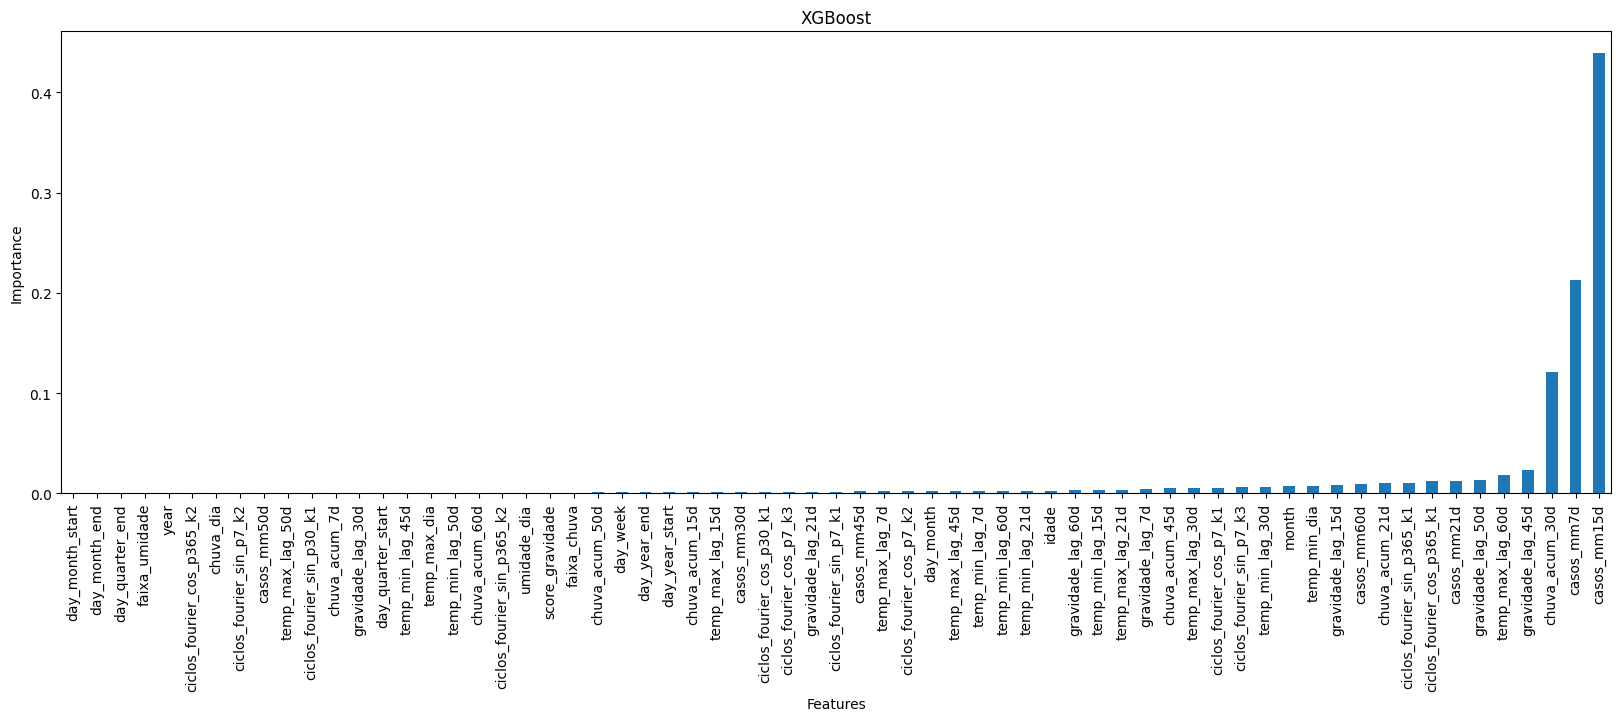

In [ ]:
feat_selected_xg_boost.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

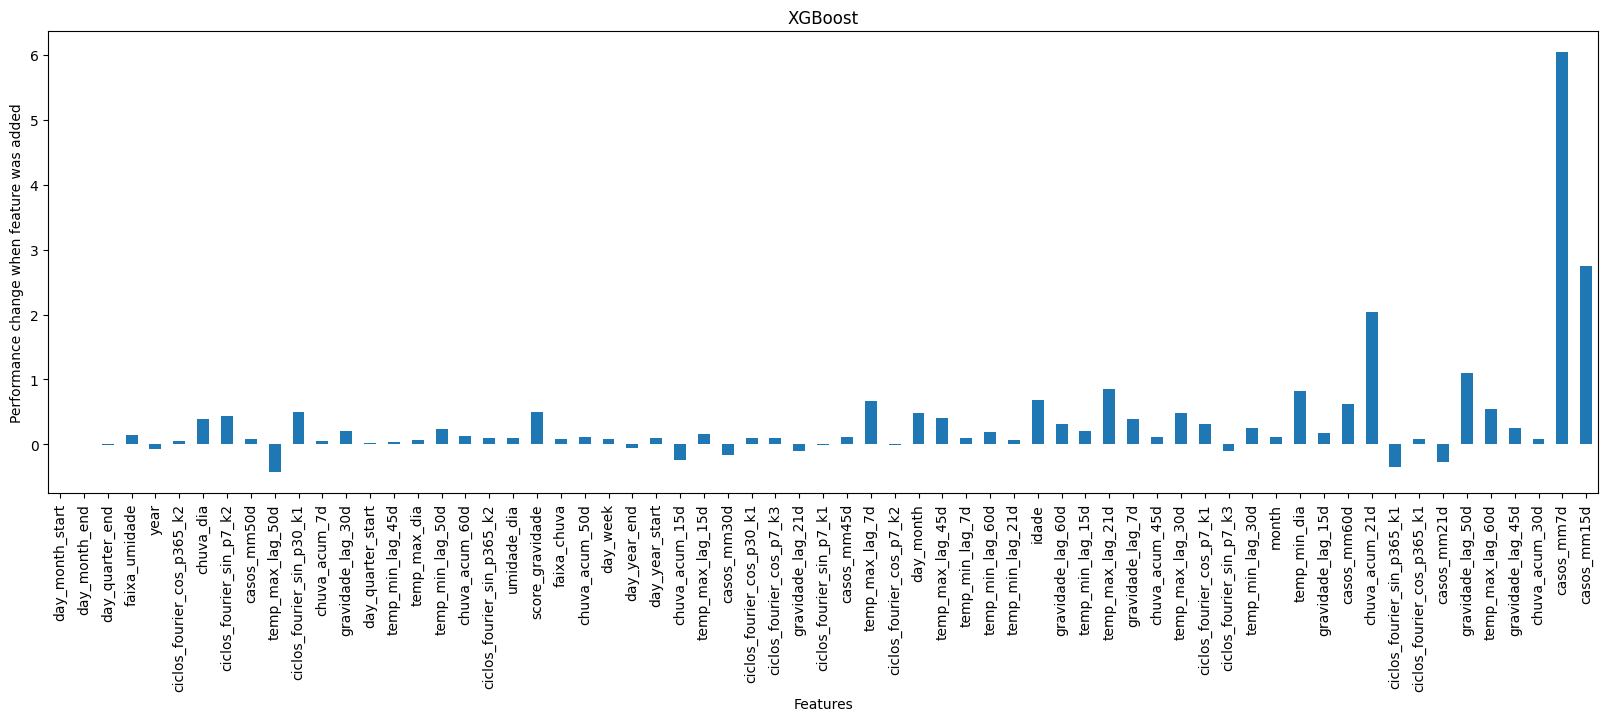

In [ ]:
pd.Series(feat_selected_xg_boost.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

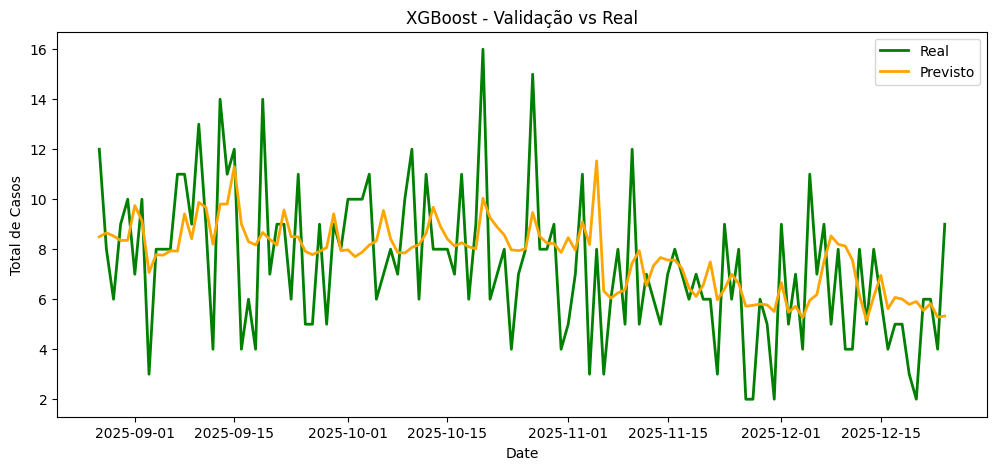

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_xg_boost, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Validação vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_val = get_erros_metric(y_val, y_pred_xg_boost, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_val)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108


In [ ]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 51),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'day_week', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'chuva_acum_30d',
        'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
        'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
        'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm45d',
        'casos_mm50d', 'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
        'day_month', 'day_quarter_start', 'day_year_start',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k2',
        'ciclos_fourier_cos_p7_k3', 'ciclos_fourier_cos_p30_k1',
      

In [ ]:
y_pred_final = model_xg_boost.predict(X_test_selected)

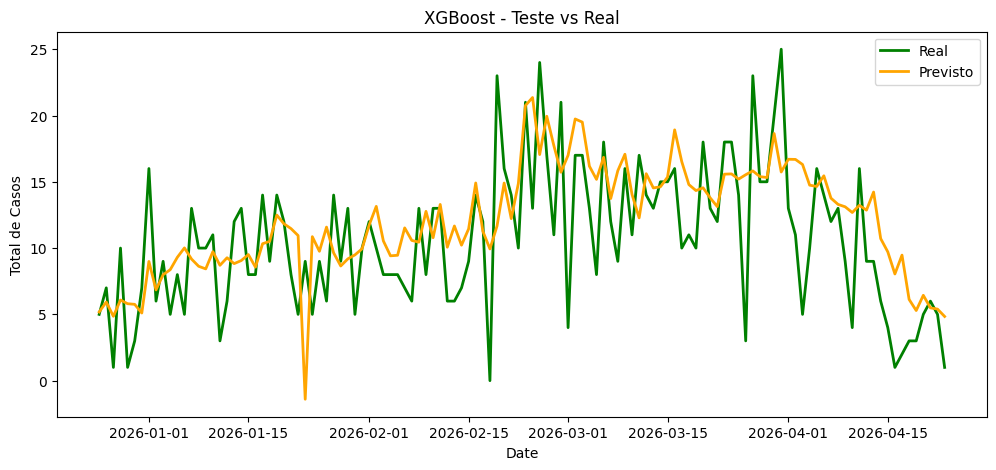

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Teste vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_test = get_erros_metric(y_test, y_pred_final, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_test)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108
1,XGBoost_test,2025-12-25,2026-04-23,3.516915,20.312428,4.506931,0.278358,4060.642108


In [ ]:
# Em séries temporais, como o seu projeto de dengue/saúde, após você validar tudo
# e chegar à conclusão de que o modelo é bom usando o `X_val`, existe um passo extra muito comum:

# **Retreinar o modelo com Treino + Validação:**
# Antes de fazer a predição final no Teste, muitos cientistas de dados juntam o Treino e
# a Validação em um único bloco e treinam o modelo uma última vez com esses dados combinados.
# Porque assim o modelo terá visto os dados mais recentes (da validação)
# antes de tentar prever o teste, o que é valioso para capturar as tendências mais próximas de 2026.

X_train_selected = X_train_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)


# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

# X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)

model_xg_boost.fit(X_final_train, y_final_train)
y_pred_final_agg = model_xg_boost.predict(X_test_selected) # Comparar com y_test

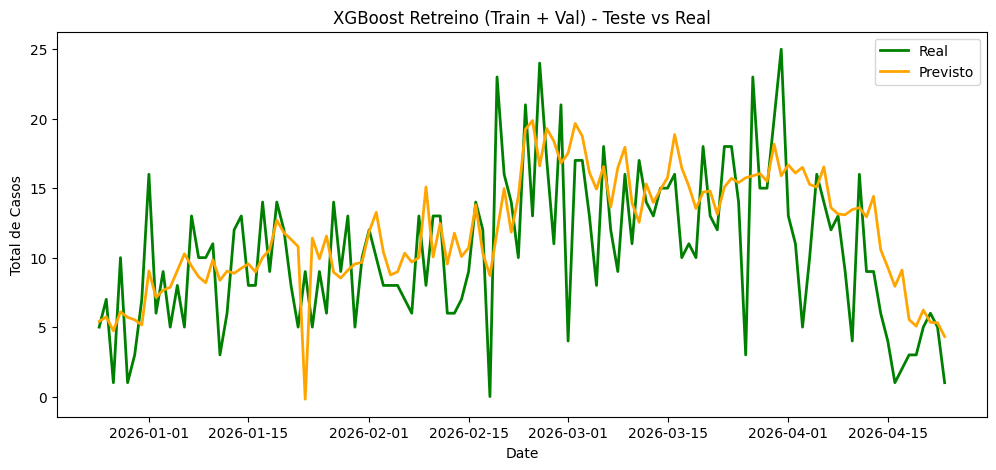

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final_agg, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Retreino (Train + Val) - Teste vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_test_agg = get_erros_metric(y_test, y_pred_final_agg, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_test_agg)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108
1,XGBoost_test,2025-12-25,2026-04-23,3.516915,20.312428,4.506931,0.278358,4060.642108
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.500269,19.951434,4.466703,0.291183,4060.642108


In [ ]:
# Como o 3.43 é melhor que o 3.58, prova que incluir o período de validação no treino final vale a pena

In [ ]:
# # Cria um novo modelo com os parâmetros otimizados que você já descobriu
# model_retrained = XGBRegressor(**best_params_xg_boost)

# # Treina no bloco combinado (Treino + Validação)
# model_retrained.fit(X_final_train, y_final_train)

In [ ]:
# modelo.fit(X_final_train, y_final_train)
# y_pred_final_retrained = model_retrained.predict(X_test_selected) # Comparar com y_test

In [ ]:
# plt.figure(figsize=(12,5))
# plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
# plt.plot(y_test.index, y_pred_final_retrained, label='Previsto', color='orange', lw=2)
# plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test Retreinado)")
# plt.xlabel("Date")
# plt.ylabel("Close")
# plt.legend()
# plt.show()

In [ ]:
# Parâmetros vs. Pesos (Aprendizado)
# Existe uma diferença crucial entre Hiperparâmetros e Pesos aprendidos:

# Hiperparâmetros (best_params): São as configurações da "máquina"
# (ex: profundidade da árvore = 5, taxa de aprendizado = 0.1).
# Eles dizem como o modelo deve aprender, mas não o que ele aprendeu.

# Pesos/Árvores aprendidas: É o conhecimento real.
# Quando você rodou o forecasting, o modelo model_xg_boost aprendeu os padrões de 2020 até agosto de 2025.

# Se você apenas usar o model_xg_boost.predict(X_test),
# ele usará o conhecimento que para em agosto de 2025 para tentar prever 2026.
# Ao rodar o .fit() novamente com os dados combinados, você não está mudando as
# "configurações" (hiperparâmetros), mas está permitindo que
# o modelo "leia os capítulos mais recentes" da história (o set de Validação).

# A "Janela de Memória" em Séries Temporais
# Sem o retreino: O modelo tenta prever o futuro com uma "lacuna" de informação
# (os 60-87 dias da validação que ele nunca viu).

# Com o retreino: O modelo encosta no "presente" antes de saltar para o futuro (Teste).
# Isso geralmente reduz drasticamente o erro (MAE) porque ele captura a inclinação da curva de casos mais recente.

# LightGBM

In [ ]:
start_time = time.time()
model_name = 'LightGBM'
y_pred_gbm, best_params_gbm, feat_selected_gbm, model_gbm, study = forecasting(
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    model_name=model_name,
    random_state=SEED,
    n_trials=n_trials,
    n_splits=n_splits,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=n_warmup_steps
)
end_time = time.time()

[I 2026-05-23 14:22:27,606] A new study created in memory with name: no-name-d892c0f8-3bea-4f1c-bcb2-e23fa30450bb
[I 2026-05-23 14:23:03,659] Trial 0 finished with value: 48.13717639461408 and parameters: {'n_estimators': 903, 'learning_rate': 0.0021239068201530857, 'num_leaves': 89, 'max_depth': 6, 'min_child_samples': 88, 'subsample': 0.6334516230839762, 'colsample_bytree': 0.9807048505310327, 'reg_alpha': 4.5015683803591475e-07, 'reg_lambda': 9.115789162413018e-06}. Best is trial 0 with value: 48.13717639461408.
[I 2026-05-23 14:23:35,344] Trial 1 finished with value: 42.333224531714265 and parameters: {'n_estimators': 481, 'learning_rate': 0.003630452832685804, 'num_leaves': 118, 'max_depth': 6, 'min_child_samples': 24, 'subsample': 0.8728043747802181, 'colsample_bytree': 0.9519025786340147, 'reg_alpha': 1.7250079777072552e-06, 'reg_lambda': 5.5075536934747044e-06}. Best is trial 1 with value: 42.333224531714265.
[I 2026-05-23 14:23:44,231] Trial 2 finished with value: 48.256955386

In [ ]:
# Histórico de Otimização (Vê se a métrica estabilizou)
# optuna.visualization.plot_optimization_history(study).show()
fig = optuna.visualization.plot_optimization_history(study)
img_name = 'optimization_history'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Importância dos Hiperparâmetros (O que realmente afetou o RMSE)
# optuna.visualization.plot_param_importances(study).show()
fig = optuna.visualization.plot_param_importances(study)
img_name = 'param_importances'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Gráfico de fatias (Slice Plot - mostra as regiões testadas para cada parâmetro)
# optuna.visualization.plot_slice(study).show()
fig = optuna.visualization.plot_slice(study)
img_name = 'slice'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
# Coordenadas Paralelas (Visualiza a relação entre todos os parâmetros e o resultado)
# optuna.visualization.plot_parallel_coordinate(study).show()
fig = optuna.visualization.plot_parallel_coordinate(study)
img_name = 'parallel_coordinate'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [ ]:
print(f'{model_name}: {best_params_gbm}')

LightGBM: {'n_estimators': 703, 'learning_rate': 0.008610845783105203, 'num_leaves': 26, 'max_depth': 3, 'min_child_samples': 12, 'subsample': 0.8233713971876977, 'colsample_bytree': 0.9689607292118334, 'reg_alpha': 0.0008722369186922979, 'reg_lambda': 3.27408095234209e-06}


In [ ]:
feat_selected_gbm.initial_model_performance_

np.float64(-64.98967986896976)

In [ ]:
len(feat_selected_gbm.features_to_drop_)

21

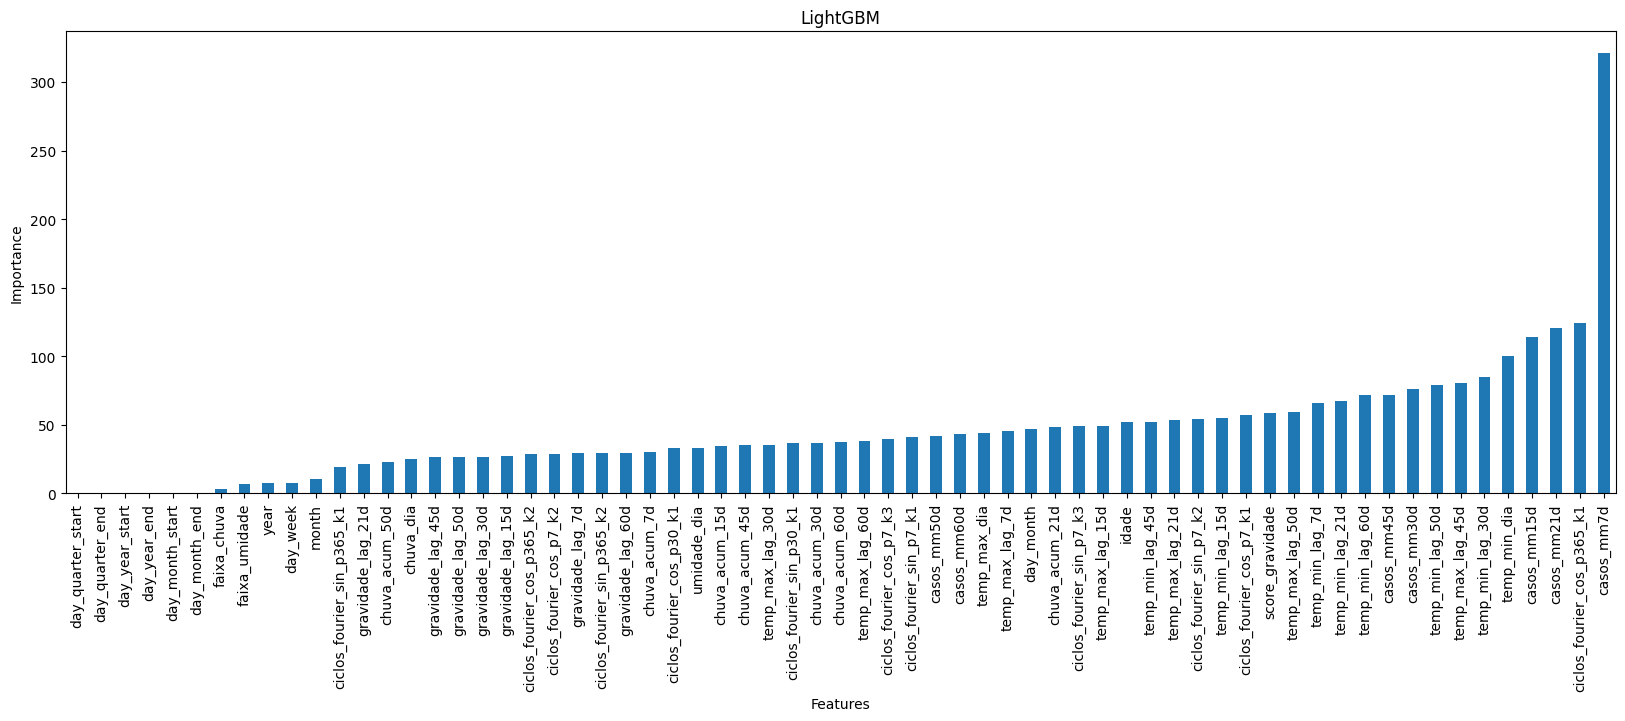

In [ ]:
feat_selected_gbm.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

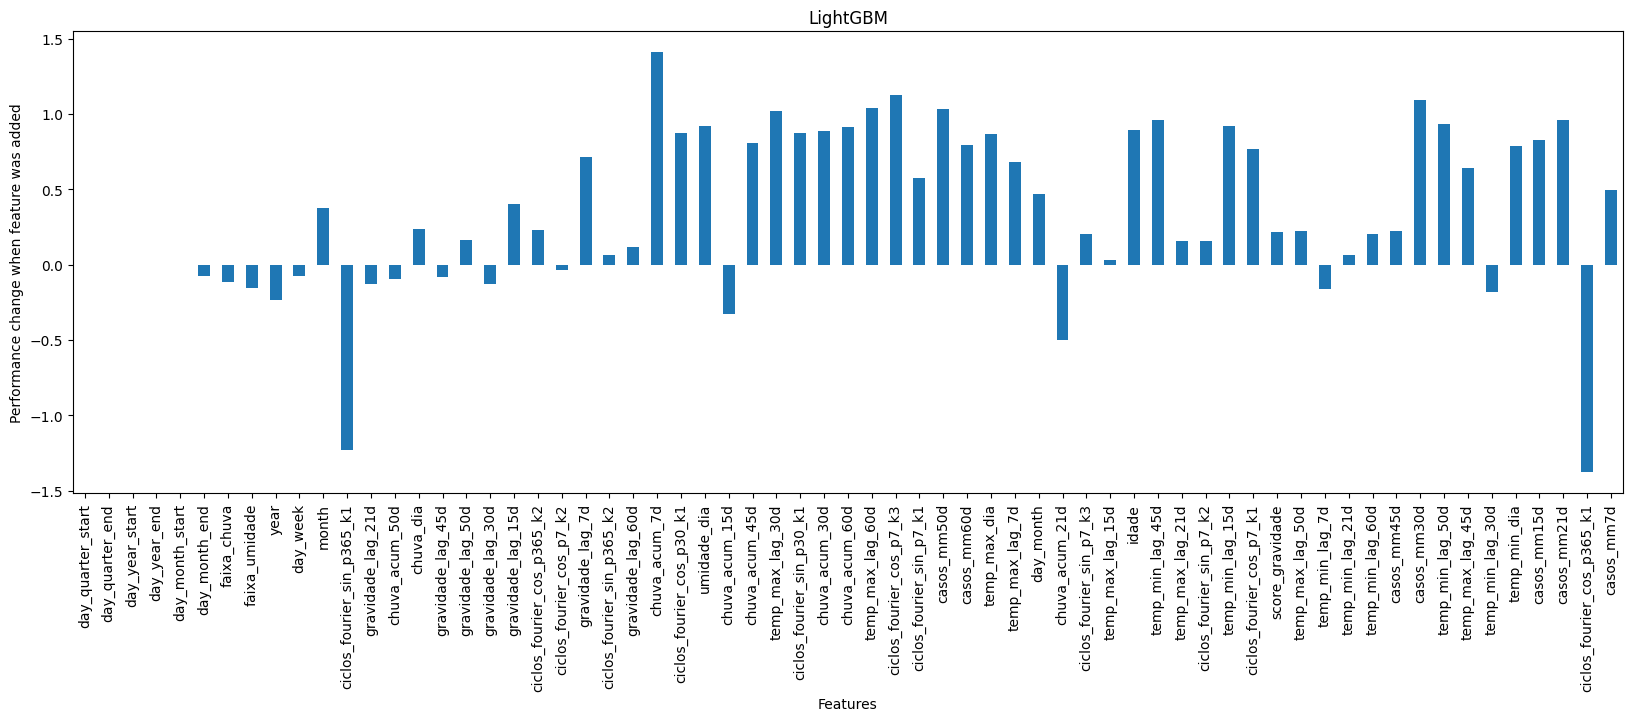

In [ ]:
pd.Series(feat_selected_gbm.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

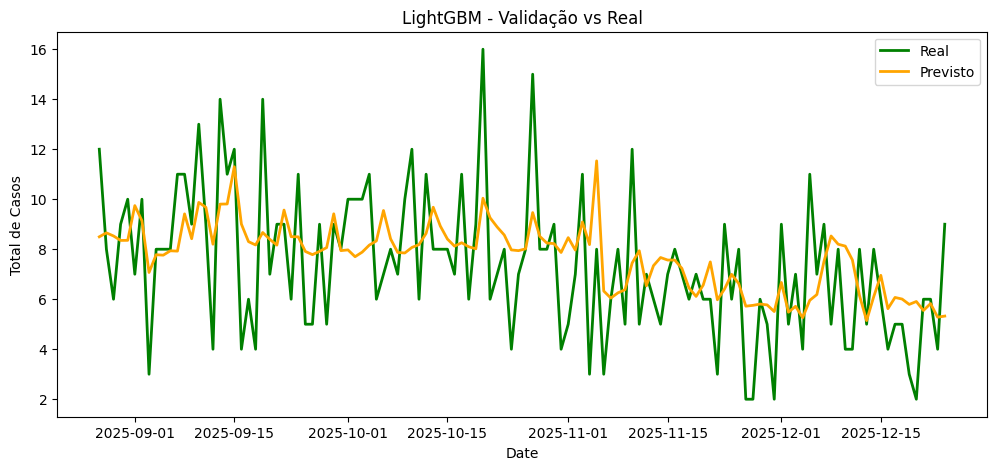

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_xg_boost, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Validação vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_ = dict()
metrics_ = get_erros_metric(y_val, y_pred_gbm, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108
1,XGBoost_test,2025-12-25,2026-04-23,3.516915,20.312428,4.506931,0.278358,4060.642108
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.500269,19.951434,4.466703,0.291183,4060.642108
3,LightGBM_val,2025-08-27,2025-12-24,2.136502,7.472359,2.733562,0.077360,3789.860110


In [ ]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 44),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_30d', 'chuva_acum_45d',
        'gravidade_lag_50d', 'chuva_acum_60d', 'gravidade_lag_60d',
        'casos_mm7d', 'casos_mm15d', 'casos_mm21d', 'casos_mm30d',
        'casos_mm45d', 'casos_mm50d', 'casos_mm60d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_45d', 'temp_min_lag_50d',
        'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
        'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
        'temp_max_lag_50d', 'temp_max_lag_60d', 'day_month',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k1',
        'ciclos_fourier_sin_p7_k2', 'ciclos_fourier_cos_p7_k3',
        'ciclos_fourier_sin_p7_k3', 'ciclos_fourier_cos_p30_k1',
        'ciclos_fourier_sin_p30_k1', 'ciclos_fourier_cos_p365_k2',
        'ciclos_fourier_sin_p365_k2'],
  

In [ ]:
y_pred_final = model_gbm.predict(X_test_selected)

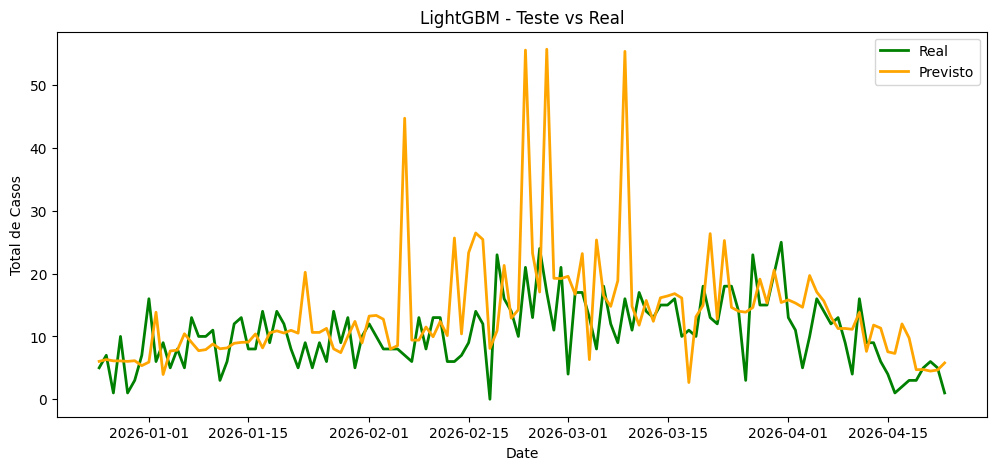

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Teste vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_final, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108
1,XGBoost_test,2025-12-25,2026-04-23,3.516915,20.312428,4.506931,0.278358,4060.642108
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.500269,19.951434,4.466703,0.291183,4060.642108
3,LightGBM_val,2025-08-27,2025-12-24,2.136502,7.472359,2.733562,0.077360,3789.860110
4,LightGBM_test,2025-12-25,2026-04-23,5.716386,83.105920,9.116245,-1.952515,3789.860110


In [ ]:
X_train_selected = X_train_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_gbm.features_to_drop_)

In [ ]:
# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

model_gbm.fit(X_final_train, y_final_train)
y_pred_final_agg = model_gbm.predict(X_test_selected) # Comparar com y_test

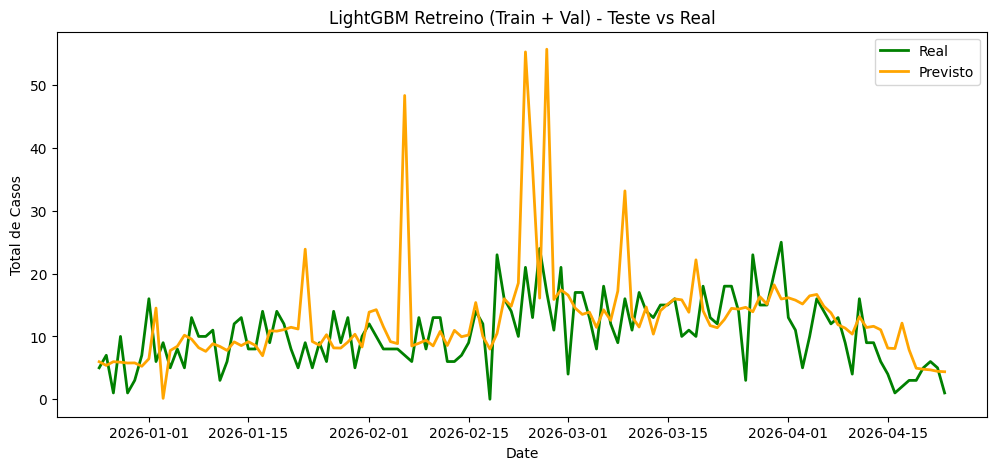

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final_agg, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Retreino (Train + Val) - Teste vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [ ]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_final_agg, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.983523,6.054784,2.460647,0.252393,4060.642108
1,XGBoost_test,2025-12-25,2026-04-23,3.516915,20.312428,4.506931,0.278358,4060.642108
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.500269,19.951434,4.466703,0.291183,4060.642108
3,LightGBM_val,2025-08-27,2025-12-24,2.136502,7.472359,2.733562,0.077360,3789.860110
4,LightGBM_test,2025-12-25,2026-04-23,5.716386,83.105920,9.116245,-1.952515,3789.860110
5,LightGBM_test_agg,2025-12-25,2026-04-23,4.916133,66.930921,8.181132,-1.377864,3789.860110
